# Netflix Movies: Trends 


**1. Introduction**
This analysis provides insights into Netflix's original film production strategy as of June 1st, 2021. It examines when content is released, the most common genres, language diversity, and audience reception via IMDB scores. The dataset includes 584 original films/documentaries

**2. Data Preparation & Cleaning**

**DateTime Conversion:** The Premiere column was converted to datetime format (errors coerced) to extract Year, Month, and Day for time-series analysis.

**Language Normalization**: Variations of "English" (e.g., "English/Japanese") were grouped into a unified "English" category to accurately represent language dominance.

**Genre Handling:** Due to high cardinality, analysis focused on the Top 10 Genres based on average IMDB score

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
df= pd.read_csv("/kaggle/input/netflix-original-films-imdb-scores/NetflixOriginals.csv")
df.head()

,Title,Genre,Premiere,Runtime,IMDB Score,Language
0,Enter the Anime,Documentary,"August 5, 2019",58,2.5,English/Japanese
1,Dark Forces,Thriller,"August 21, 2020",81,2.6,Spanish
2,The App,Science fiction/Drama,"December 26, 2019",79,2.6,Italian
3,The Open House,Horror thriller,"January 19, 2018",94,3.2,English
4,Kaali Khuhi,Mystery,"October 30, 2020",90,3.4,Hindi


**EDA**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 584 entries, 0 to 583
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Title       584 non-null    object 
 1   Genre       584 non-null    object 
 2   Premiere    584 non-null    object 
 3   Runtime     584 non-null    int64  
 4   IMDB Score  584 non-null    float64
 5   Language    584 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 27.5+ KB


In [4]:
df.describe()

,Runtime,IMDB Score
count,584.000000,584.000000
mean,93.577055,6.271747
std,27.761683,0.979256
min,4.000000,2.500000
25%,86.000000,5.700000
50%,97.000000,6.350000
75%,108.000000,7.000000
max,209.000000,9.000000


In [5]:
df.nunique()

Title         584
Genre         115
Premiere      390
Runtime       124
IMDB Score     54
Language       38
dtype: int64

In [6]:
# change the data type of premiere from object to datetime
df['Premiere'] = pd.to_datetime(df['Premiere'],  errors='coerce')

In [7]:
print(df['Premiere'].dtype) 

# Extracting date, month & year from date
df['Year'] = df['Premiere'].dt.strftime('%Y')
df['Month'] = df['Premiere'].dt.strftime('%m') # Use %m for month number
df['Day'] = df['Premiere'].dt.strftime('%d') # Use %d for day number
df.head()

datetime64[ns]


,Title,Genre,Premiere,Runtime,IMDB Score,Language,Year,Month,Day
0,Enter the Anime,Documentary,2019-08-05,58,2.5,English/Japanese,2019,08,05
1,Dark Forces,Thriller,2020-08-21,81,2.6,Spanish,2020,08,21
2,The App,Science fiction/Drama,2019-12-26,79,2.6,Italian,2019,12,26
3,The Open House,Horror thriller,2018-01-19,94,3.2,English,2018,01,19
4,Kaali Khuhi,Mystery,2020-10-30,90,3.4,Hindi,2020,10,30


In [8]:
df.groupby("Genre")['IMDB Score'].mean().sort_values(ascending=False)
# Top genre was 'Animation/Christmas/Comedy/Adventure'

Genre
Animation/Christmas/Comedy/Adventure    8.200000
Musical / Short                         7.700000
Concert Film                            7.633333
Anthology/Dark comedy                   7.600000
Animation / Science Fiction             7.500000
                                          ...   
Superhero-Comedy                        4.400000
Horror anthology                        4.300000
Political thriller                      4.300000
Musical/Western/Fantasy                 3.900000
Heist film/Thriller                     3.700000
Name: IMDB Score, Length: 115, dtype: float64

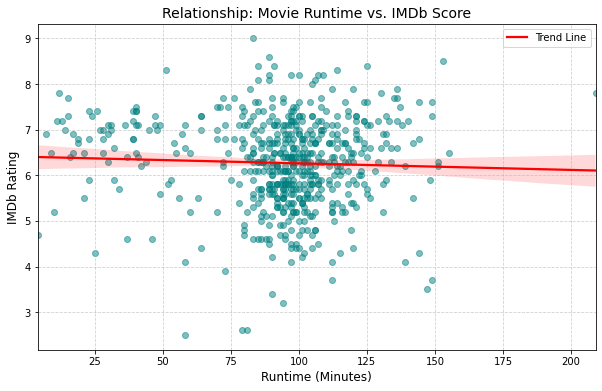

In [9]:
plt.figure(figsize=(10, 6))
# regplot creates a scatter plot with a regression line to show the trend
sns.regplot(data=df, x='Runtime', y='IMDB Score', 
            scatter_kws={'alpha':0.5, 'color':'teal'}, 
            line_kws={'color':'red', 'label':'Trend Line'})

# 3. Formatting
plt.title('Relationship: Movie Runtime vs. IMDb Score', fontsize=14)
plt.xlabel('Runtime (Minutes)', fontsize=12)
plt.ylabel('IMDb Rating', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Trend line appears nearly horizontal and lose to y-axis. This suggest there is little or no relation between runtime and IMDB Score.. we can infer that longer runtime doesnot neessarily mean higher or lower IMDB score.

As there are 38 unique value in Language. so we wil To group multiple variations of "English in one(English)

In [10]:
# 2. Define Mapping (Club everything containing 'English' into 'English', Indian languages in Indian And Spanish Language in Spanish)
# Use regex=True to find substrings, or specify exact matches
mapping = {
    'English/Ukranian/Russian': 'English',
    'English/Akan': 'English',
    'English/Hindi': 'English',
    'English/Arabic': 'English',
    'English/Korean': 'English',
    'English/Russian': 'English',
    'Khmer/English/French': 'English',
    'English/Mandarin': 'English',
    'Thia/English': 'English',
    'English/Taiwanese/Mandarin': 'English',
    'English/Swedish': 'English',
    'English': 'English',
    'English/Spanish': 'English',
    'English/Japanese': 'English',
    'Tamil': 'Indian',
    'Bengali': 'Indian',
    'Marathi': 'Indian',
    'Hindi': 'Indian',
    'Spanish/English': 'Spanish',
    'Spanish/Catalan': 'Spanish',
    'Spanish/Basque' : 'Spanish'
    }

# 3. Replace values in the DataFrame
df['Language'] = df['Language'].replace(mapping)

# 4. Group by the normalized language
lang_scores = df.groupby('Language')['IMDB Score'].mean().sort_values(ascending=False)
top_10_langs = lang_scores.head(10).reset_index()
top_10_langs

,Language,IMDB Score
0,Georgian,6.800000
1,Japanese,6.400000
2,English,6.394062
3,Spanish,6.314706
4,Portuguese,6.216667
5,Indian,6.050000
6,Korean,5.916667
7,Indonesian,5.844444
8,Dutch,5.800000
9,French,5.770000


Top Movie Languages by Average IMDb Score:
                mean  count
Language                   
Japanese    6.400000      6
English     6.394062    421
Spanish     6.314706     34
Portuguese  6.216667     12
Indian      6.050000     38
Korean      5.916667      6
Indonesian  5.844444      9
French      5.770000     20
Italian     5.542857     14


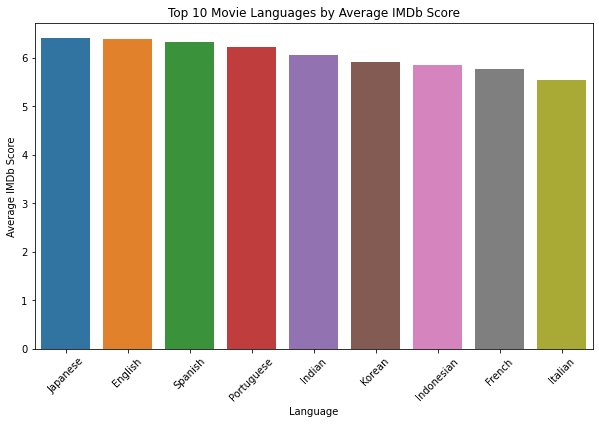

In [11]:
# 2. Data Cleaning: Drop rows with missing language or scores
df = df.dropna(subset=['Language', 'IMDB Score'])

# 3. Group by language and calculate the mean IMDb score
# We also count the number of movies to ensure a minimum sample size
language_stats = df.groupby('Language')['IMDB Score'].agg(['mean', 'count'])

# 4. Filter: Only include languages with more than 5 movies to avoid skew
# (Optional, but recommended)
top_languages = language_stats[language_stats['count'] > 5]

# 5. Sort by mean score in descending order
top_languages = top_languages.sort_values(by='mean', ascending=False)

# Display the top 10 languages
print("Top Movie Languages by Average IMDb Score:")
print(top_languages.head(10))

# 6. Optional: Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x=top_languages.head(10).index, y=top_languages.head(10)['mean'])
plt.title('Top 10 Movie Languages by Average IMDb Score')
plt.ylabel('Average IMDb Score')
plt.xlabel('Language')
plt.xticks(rotation=45)
plt.show()

# We can infer: though Japanese mpvies count is low but it has received top ranking whereas English count is 412 still its on 2nd raank 

Genre
Documentary                             9.0
One-man show                            8.5
Concert Film                            8.4
Animation/Christmas/Comedy/Adventure    8.2
Drama                                   7.9
Animation / Short                       7.8
Crime drama                             7.8
Musical / Short                         7.7
Making-of                               7.7
War drama                               7.7
Name: IMDB Score, dtype: float64


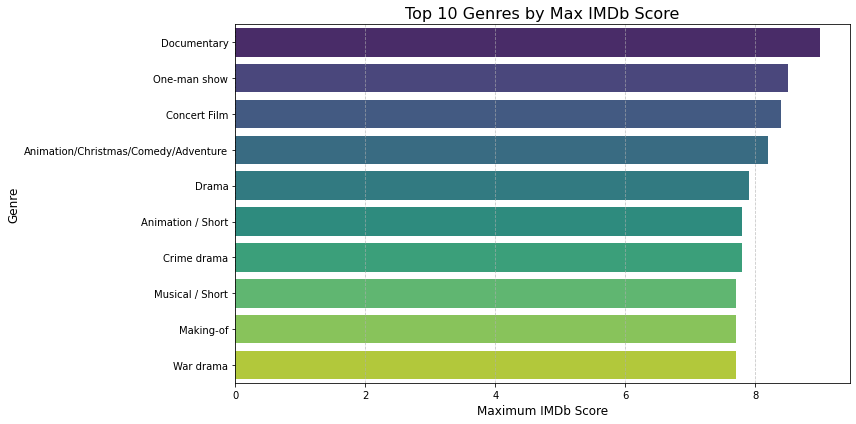

In [12]:
# 3. Find Maximum IMDB Score per Genre
genre_max_scores = df.groupby('Genre')['IMDB Score'].max().sort_values(ascending=False)

# Get the Top 10 Genres with the highest scores for a cleaner chart
top_10_genres = genre_max_scores.head(10)
print(top_10_genres)

# 4. Depict the Chart
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_genres.values, y=top_10_genres.index, palette='viridis')

plt.title('Top 10 Genres by Max IMDb Score', fontsize=16)
plt.xlabel('Maximum IMDb Score', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

As there are too many Genre, it will look mess if I plot all of them in a single plot, also we won't be able to interprete it. So, I will plot the top 10 Genre based on the average IMDB Score.
Hence it was observed that Documentary receved highest IMDB Score

In [13]:
release_per_year= df.groupby("Year").size().reset_index(name = 'count')
release_per_year
Max_release_per_year = release_per_year.loc[release_per_year['count'].idxmax()]
Max_release_per_year
# MAx no of movies (183) has been released in OCober 2020 

Year     2020
count     183
Name: 6, dtype: object

In [14]:
release_per_month =  df.groupby('Month').size().reset_index(name = 'count') 
release_per_month
max_release_per_month= release_per_month.loc[release_per_month['count'].idxmax()]
max_release_per_month
# Max no of movies released in the month of October

Month    10
count    77
Name: 9, dtype: object

In [15]:
# Group by month and count releases
release_per_month = df.groupby('Month').size().reset_index(name='count')
# Sort by month number for correct order in plot
max_release_per_month['Month'] = df.groupby('Month')['Month'].first().values
max_release_per_month = release_per_month.sort_values('Month')
max_release_per_month = release_per_month.loc[release_per_month['count'].idxmax()]

print(f"Maximum movies were released in the year: {Max_release_per_year['Year']} with {Max_release_per_year['count']} releases.")
print(f"Maximum movies were released in the month: {max_release_per_month['Month']} with {max_release_per_month ['count']} releases.")

Maximum movies were released in the year: 2020 with 183 releases.
Maximum movies were released in the month: 10 with 77 releases.


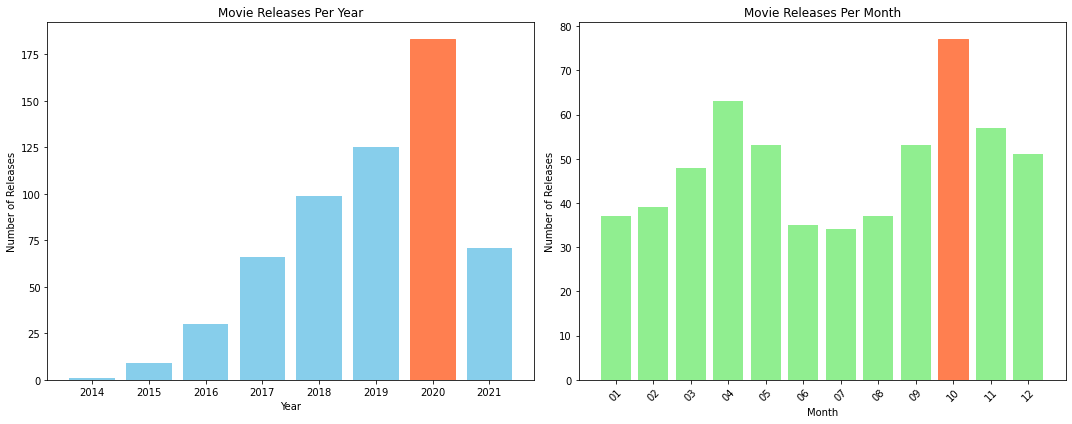

In [16]:
 #3. Create subplots for year and month
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot for year
axes[0].bar(release_per_year['Year'], release_per_year['count'], color='skyblue')
axes[0].set_title('Movie Releases Per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Releases')
axes[0].set_xticks(release_per_year['Year']) # Ensure all years are shown

# Highlight max year in plot (optional)
axes[0].patches[release_per_year['count'].idxmax()].set_color('coral')

# Plot for month
axes[1].bar(release_per_month['Month'], release_per_month['count'], color='lightgreen')
axes[1].set_title('Movie Releases Per Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of Releases')
axes[1].tick_params(axis='x', rotation=45) # Rotate labels for readability

# Highlight max month in plot (optional)
axes[1].patches[release_per_month['count'].idxmax()].set_color('coral')

plt.tight_layout() # Adjust layout to prevent overlap
plt.show()

# 2020 was the era of Covid. World wide lockdown made people aptive of home. They prefer to watch movies .hence more movies were released during that era. october was the month of 

**3. Key Findings**

**Production Volume Trends**

**Release Peak******: The highest number of movies were released in 2020 with 183 releases, showcasing a massive surge in content, likely accelerated by the COVID-19 pandemic.

**Monthly Trend:** October is the most popular month for releases (77 releases), suggesting a strategy focusing on year-end viewing